In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [2]:
# Pandas detecta el ZIP y lee el archivo interno automáticamente
df = pd.read_csv('DATA/heart+failure+clinical+records.zip', compression='zip')

print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [3]:
print(f"Dimensiones del dataset original: {df.shape}")

Dimensiones del dataset original: (299, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


## Análisis de Variables Numéricas

#### Histogramas

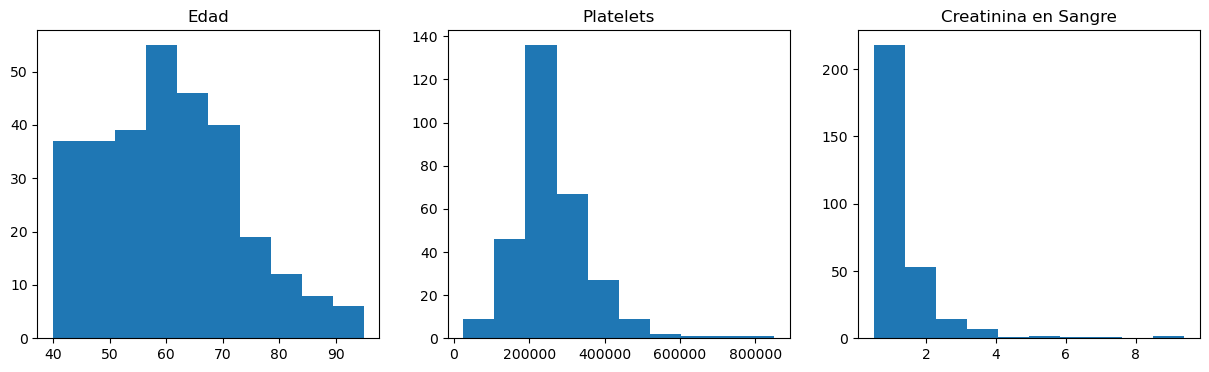

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(df['age'])
ax[0].set_title('Edad')
ax[1].hist(df['platelets'])
ax[1].set_title('Platelets')
ax[2].hist(df['serum_creatinine'])
ax[2].set_title('Creatinina en Sangre')

plt.show()

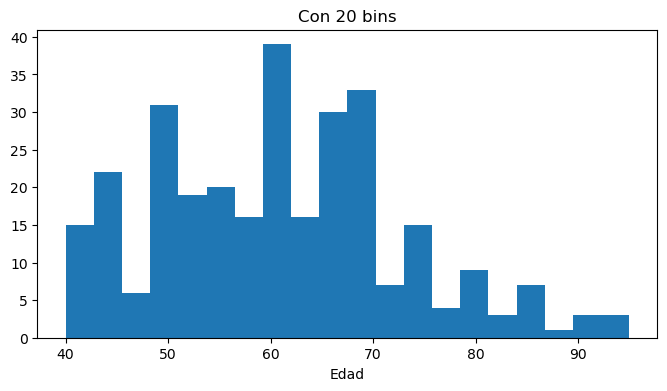

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

# Debes usar 'ax.' antes de cada instrucción
ax.hist(df['age'], bins=20)
ax.set_title('Con 20 bins')
ax.set_xlabel('Edad')

plt.show()

### 1. Medidas de tendencia central: media, mediana y moda
<hr style="border:1px solid gray">

#### Media

In [7]:
df['age'].mean()

60.83389297658862

In [8]:
df['platelets'].mean()

263358.02926421404

In [9]:
df['serum_creatinine'].mean()

1.3938795986622072

#### Mediana

In [10]:
df['age'].median()

60.0

In [11]:
df['platelets'].median()

262000.0

In [12]:
df['serum_creatinine'].median()

1.1

#### Moda

In [13]:
df['age'].mode()

0    60.0
Name: age, dtype: float64

In [14]:
df['platelets'].mode()

0    263358.03
Name: platelets, dtype: float64

In [15]:
df['serum_creatinine'].mode()

0    1.0
Name: serum_creatinine, dtype: float64

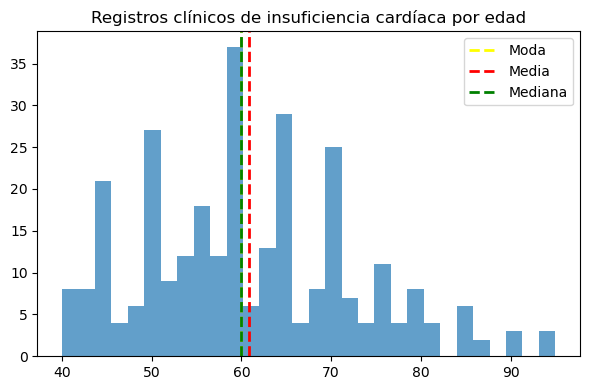

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['age'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(df['age'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df['age'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df['age'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Registros clínicos de insuficiencia cardíaca por edad')
ax.legend()

plt.tight_layout()
plt.show()

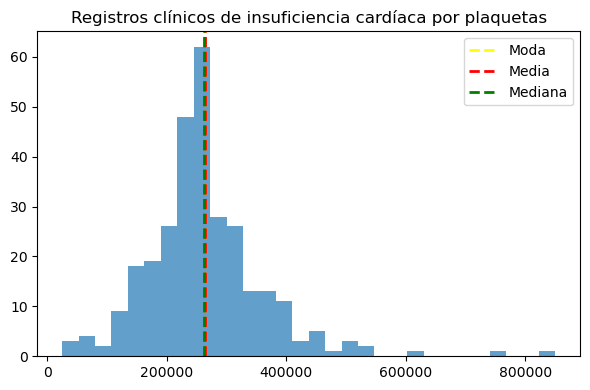

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['platelets'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(df['platelets'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df['platelets'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df['platelets'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Registros clínicos de insuficiencia cardíaca por plaquetas')
ax.legend()

plt.tight_layout()
plt.show()

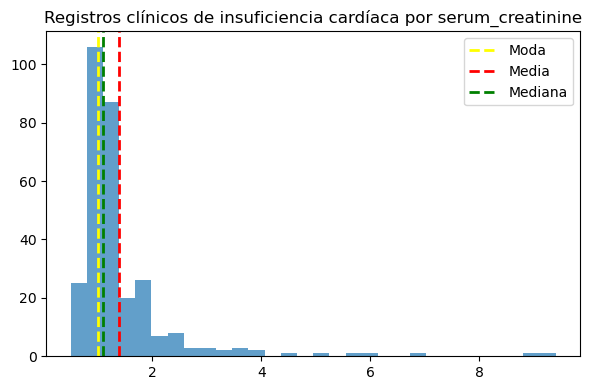

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['serum_creatinine'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(df['serum_creatinine'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df['serum_creatinine'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df['serum_creatinine'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Registros clínicos de insuficiencia cardíaca por serum_creatinine')
ax.legend()

plt.tight_layout()
plt.show()

#### KDE: Kernel Density Estimation --> estimar la función de densidad de probabilidad (PDF)

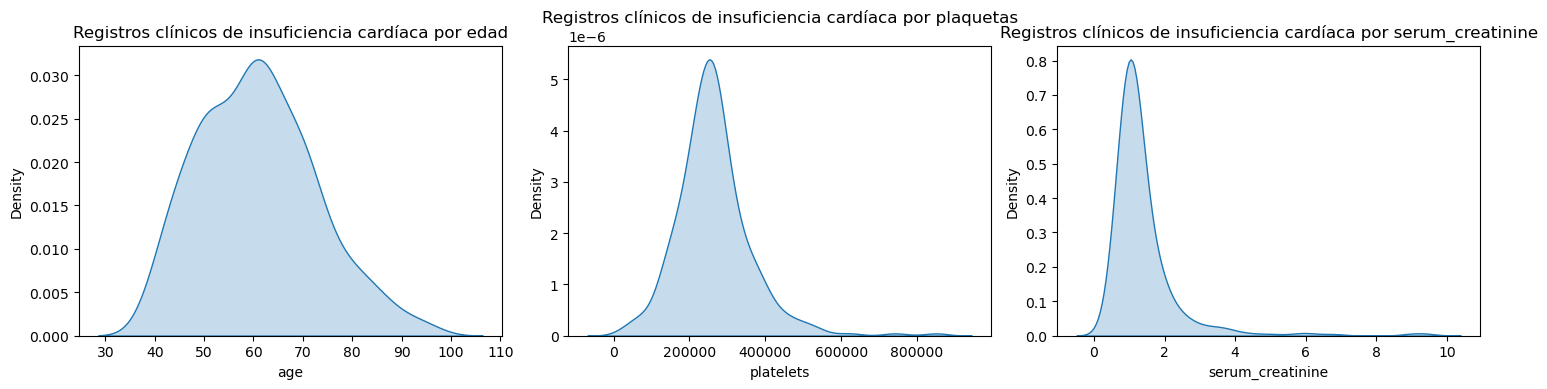

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(data=df, x='age', fill=True, ax=axes[0])
sns.kdeplot(data=df, x='platelets', fill=True, ax=axes[1])
sns.kdeplot(data=df, x='serum_creatinine', fill=True, ax=axes[2])
axes[0].set_title('Registros clínicos de insuficiencia cardíaca por edad')
axes[1].set_title('Registros clínicos de insuficiencia cardíaca por plaquetas')
axes[2].set_title('Registros clínicos de insuficiencia cardíaca por serum_creatinine')

plt.tight_layout()
plt.show()

### 2. Medidas de dispersión: varianza y desviación estándar
<hr style="border:1px solid gray">

In [22]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
media = df['age'].mean()
var = df['age'].var()
std_dev = df['age'].std()
print(f'La media de la edad {media:.2f} años., \nla varianza es {var:.4f} años. y \nla desviación estándar es {std_dev:.4f} años.')

La media de la edad 60.83 años., 
la varianza es 141.4865 años. y 
la desviación estándar es 11.8948 años.


In [24]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
media = df['platelets'].mean()
var = df['platelets'].var()
std_dev = df['platelets'].std()
print(f'La media de la edad {media:.2f}., \nla varianza es {var:.4f}. y \nla desviación estándar es {std_dev:.4f}.')

La media de la edad 263358.03., 
la varianza es 9565668749.4489. y 
la desviación estándar es 97804.2369.


In [25]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
media = df['serum_creatinine'].mean()
var = df['serum_creatinine'].var()
std_dev = df['serum_creatinine'].std()
print(f'La media de la edad {media:.2f}., \nla varianza es {var:.4f}. y \nla desviación estándar es {std_dev:.4f}.')

La media de la edad 1.39., 
la varianza es 1.0702. y 
la desviación estándar es 1.0345.


<Axes: xlabel='serum_creatinine', ylabel='Density'>

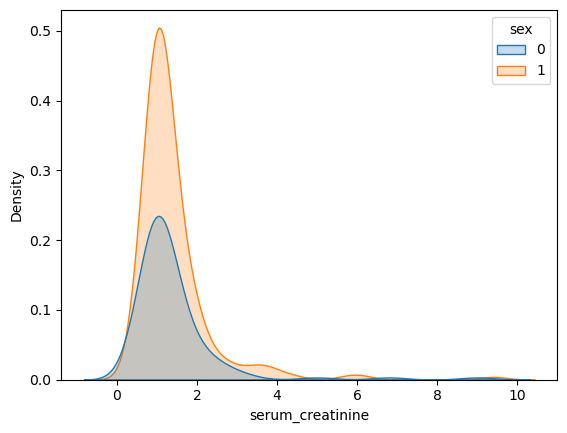

In [27]:
sns.kdeplot(data=df, x='serum_creatinine', hue='sex', fill=True)

<Axes: xlabel='platelets', ylabel='Density'>

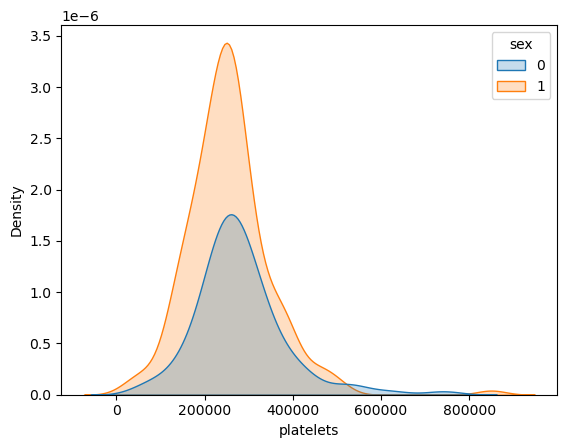

In [28]:
sns.kdeplot(data=df, x='platelets', hue='sex', fill=True)

<Axes: xlabel='age', ylabel='Density'>

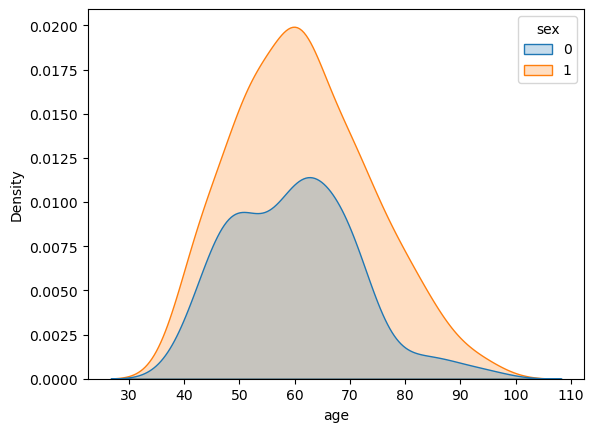

In [29]:
sns.kdeplot(data=df, x='age', hue='sex', fill=True)

### 3. Cuantiles y rango intercuartil
<hr style="border:1px solid gray">

In [37]:
Q1 = df['age'].quantile(0.25)
Q2 = df['age'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q3 = df['age'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

Q1 (25%): 51.0
Q2 (Mediana, 50%): 60.0
Q3 (75%): 70.0


In [32]:
Q1 = df['platelets'].quantile(0.25)
Q2 = df['platelets'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q3 = df['platelets'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

Q1 (25%): 212500.0
Q2 (Mediana, 50%): 262000.0
Q3 (75%): 303500.0


In [33]:
Q1 = df['serum_creatinine'].quantile(0.25)
Q2 = df['serum_creatinine'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q3 = df['serum_creatinine'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

Q1 (25%): 0.9
Q2 (Mediana, 50%): 1.1
Q3 (75%): 1.4


#### Visualizamos estas variables con Boxplots

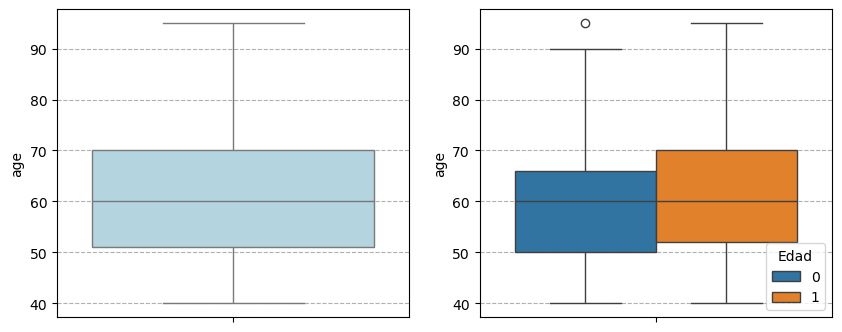

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='age', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='age', hue='sex', ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='Edad', loc='lower right')


plt.show()

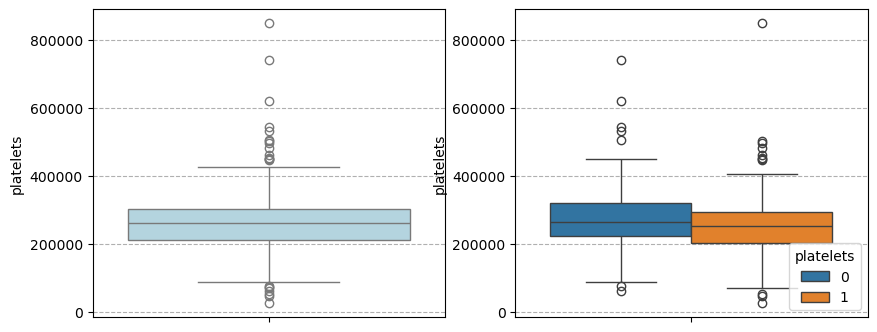

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='platelets', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='platelets', hue='sex', ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='platelets', loc='lower right')

plt.show()

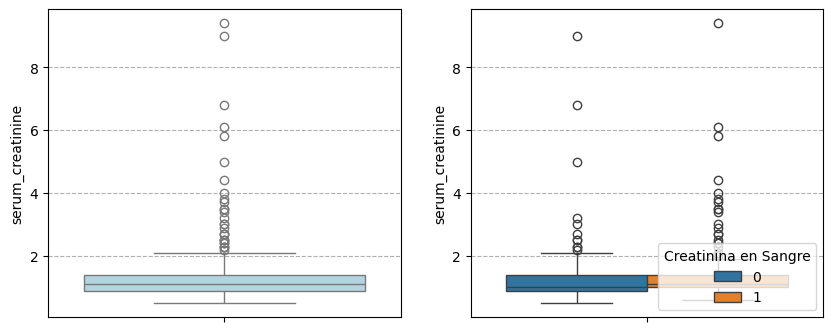

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='serum_creatinine', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='serum_creatinine', hue='sex', ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='Creatinina en Sangre', loc='lower right')

plt.show()

Hay muchos Outliers

### 4. Medidas de forma: skewness (asimetría) y curtosis
<hr style="border:1px solid gray">

In [41]:
print(f"Asímetría de la variable Edad: {df['age'].skew()}")
print(f"Curtosis de la variable Edad: {df['age'].kurtosis()}")

print(f"Asímetría de la variable Edad: {df['platelets'].skew()}")
print(f"Curtosis de la variable Edad: {df['platelets'].kurtosis()}")

print(f"Asímetría de la variable Edad: {df['serum_creatinine'].skew()}")
print(f"Curtosis de la variable Edad: {df['serum_creatinine'].kurtosis()}")

Asímetría de la variable Edad: 0.42306190672863536
Curtosis de la variable Edad: -0.18487053195417413
Asímetría de la variable Edad: 1.4623208382757793
Curtosis de la variable Edad: 6.209254515302208
Asímetría de la variable Edad: 4.455995882049026
Curtosis de la variable Edad: 25.828238661132016


In [42]:
print("Estadística descriptiva del dataset :\n", df.describe())

Estadística descriptiva del dataset :
               age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
2

## Análisis de las variables categóricas
<hr style="border:1px solid gray">

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [44]:
# Convertimos columnas del dataset del Titanic al tipo correcto
df['anaemia'] = df['anaemia'].astype('category')
df['sex'] = df['sex'].astype('category')
df['diabetes'] = df['diabetes'].astype('category')
df['smoking'] = df['smoking'].astype('category')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       299 non-null    float64 
 1   anaemia                   299 non-null    category
 2   creatinine_phosphokinase  299 non-null    int64   
 3   diabetes                  299 non-null    category
 4   ejection_fraction         299 non-null    int64   
 5   high_blood_pressure       299 non-null    int64   
 6   platelets                 299 non-null    float64 
 7   serum_creatinine          299 non-null    float64 
 8   serum_sodium              299 non-null    int64   
 9   sex                       299 non-null    category
 10  smoking                   299 non-null    category
 11  time                      299 non-null    int64   
 12  DEATH_EVENT               299 non-null    int64   
dtypes: category(4), float64(3), int64(6)
memory usage:

In [46]:
df.describe(include='category')

,anaemia,diabetes,sex,smoking
count,299,299,299,299
unique,2,2,2,2
top,0,0,1,0
freq,170,174,194,203


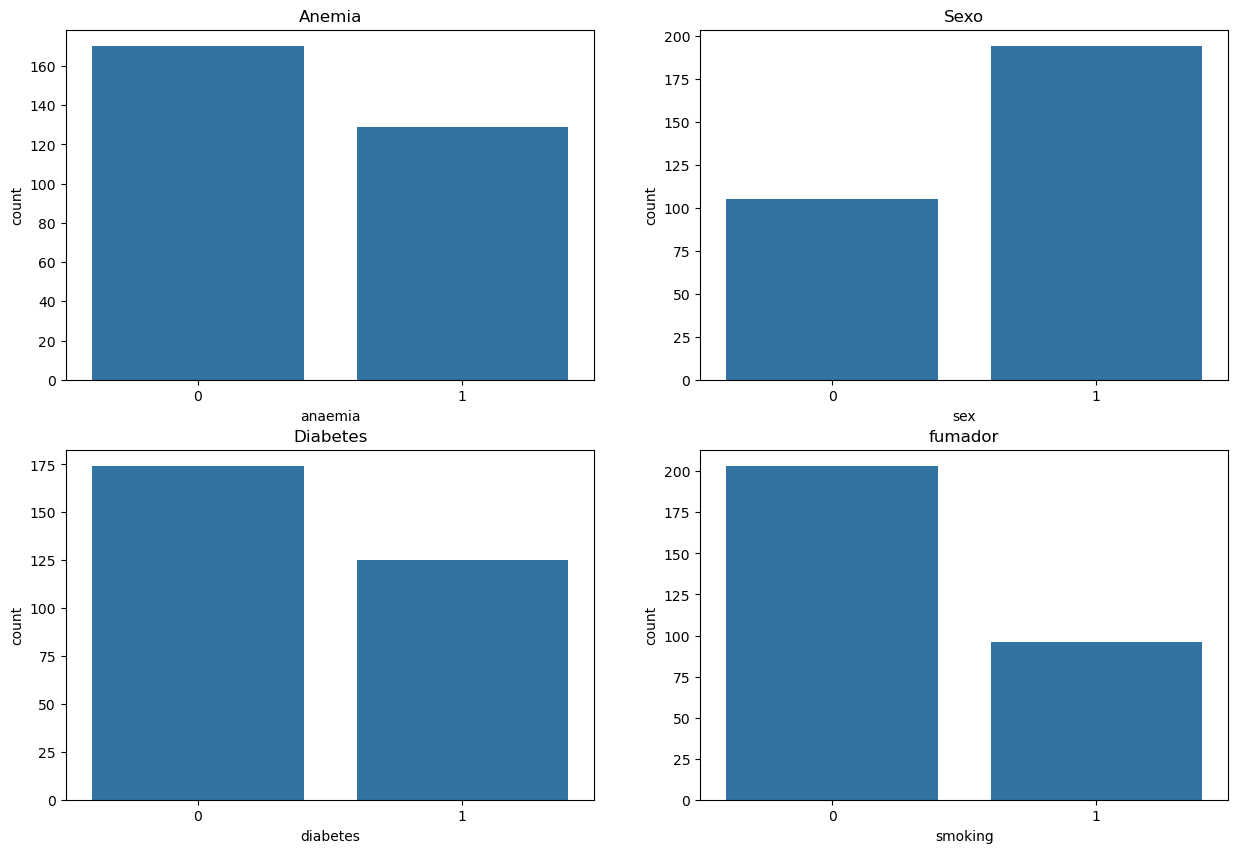

In [47]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Gráficos de barras de cada una
sns.countplot(x='anaemia', data=df, ax=ax[0,0])
sns.countplot(x='sex', data=df, ax=ax[0,1])
sns.countplot(x='diabetes', data=df, ax=ax[1,0])
sns.countplot(x='smoking', data=df, ax=ax[1,1])

# Títulos
ax[0,0].set_title('Anemia')
ax[0,1].set_title('Sexo')
ax[1,0].set_title('Diabetes')
ax[1,1].set_title('fumador')

plt.show()

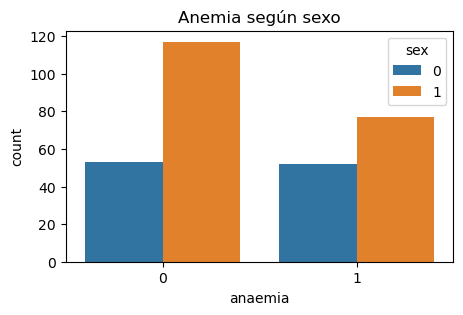

In [48]:
# Cuántas personas sobrevivieron de cada sexo?
plt.figure(figsize=(5, 3))
sns.countplot(x='anaemia', hue='sex', data=df)
plt.title("Anemia según sexo")
plt.show()

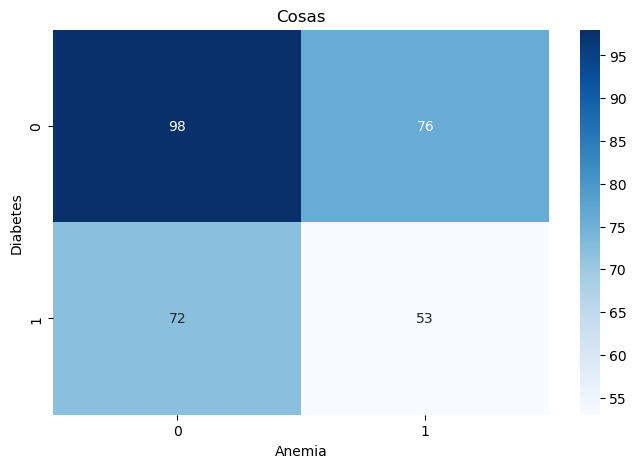

In [49]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['diabetes'], df['anaemia'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Cosas')
plt.xlabel('Anemia')
plt.ylabel('Diabetes')
plt.show()

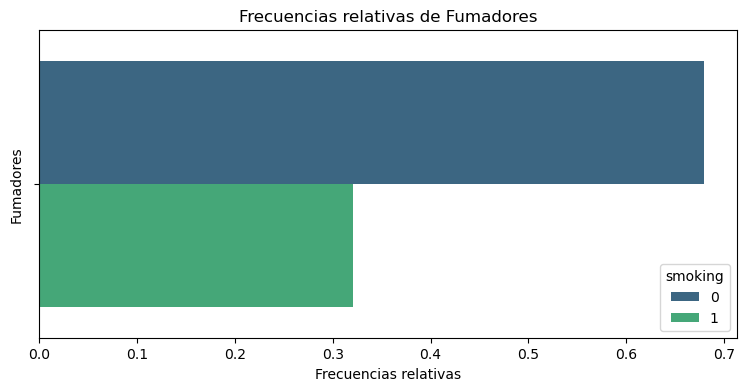

In [50]:
# Calcular frecuencias relativas
total = len(df)
relative_freq = df['smoking'].value_counts() / total

# Graficar frecuencias relativas
plt.figure(figsize=(9, 4))
sns.barplot(x=relative_freq.values, hue=relative_freq.index, palette='viridis')
plt.title('Frecuencias relativas de Fumadores')
plt.xlabel('Frecuencias relativas')
plt.ylabel('Fumadores')
plt.show()

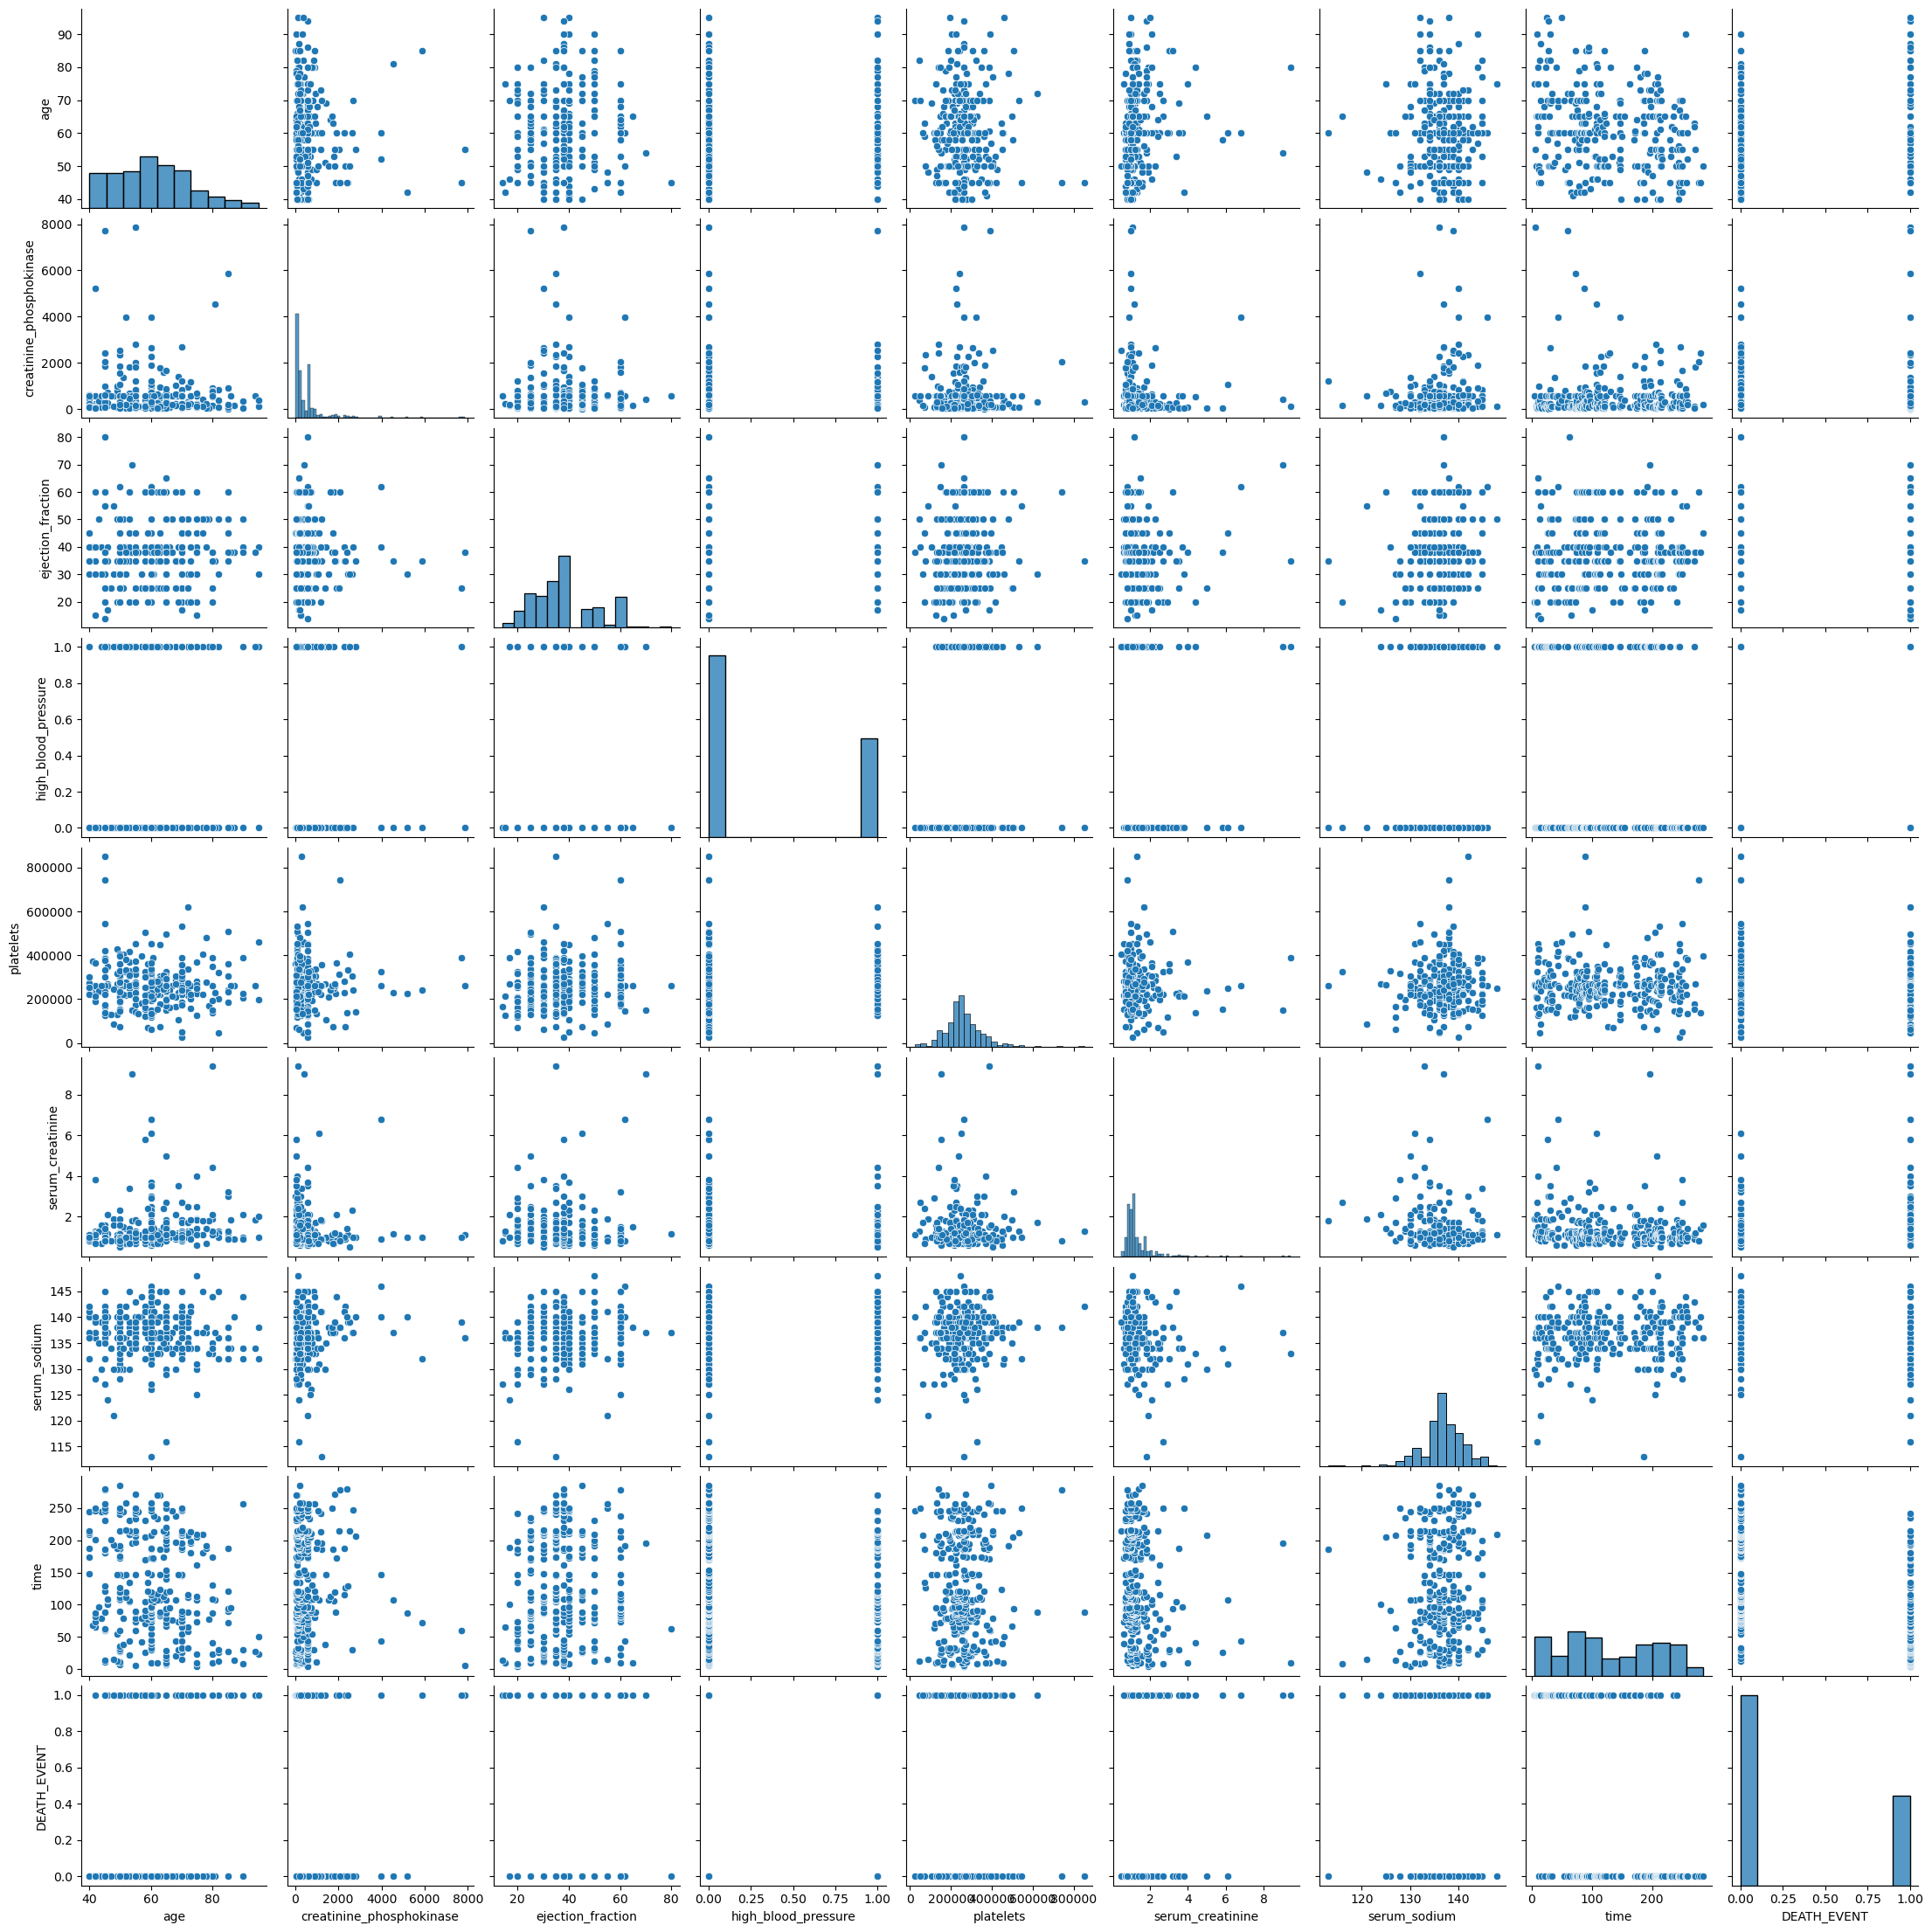

In [55]:
sns.pairplot(data=df)
plt.show()

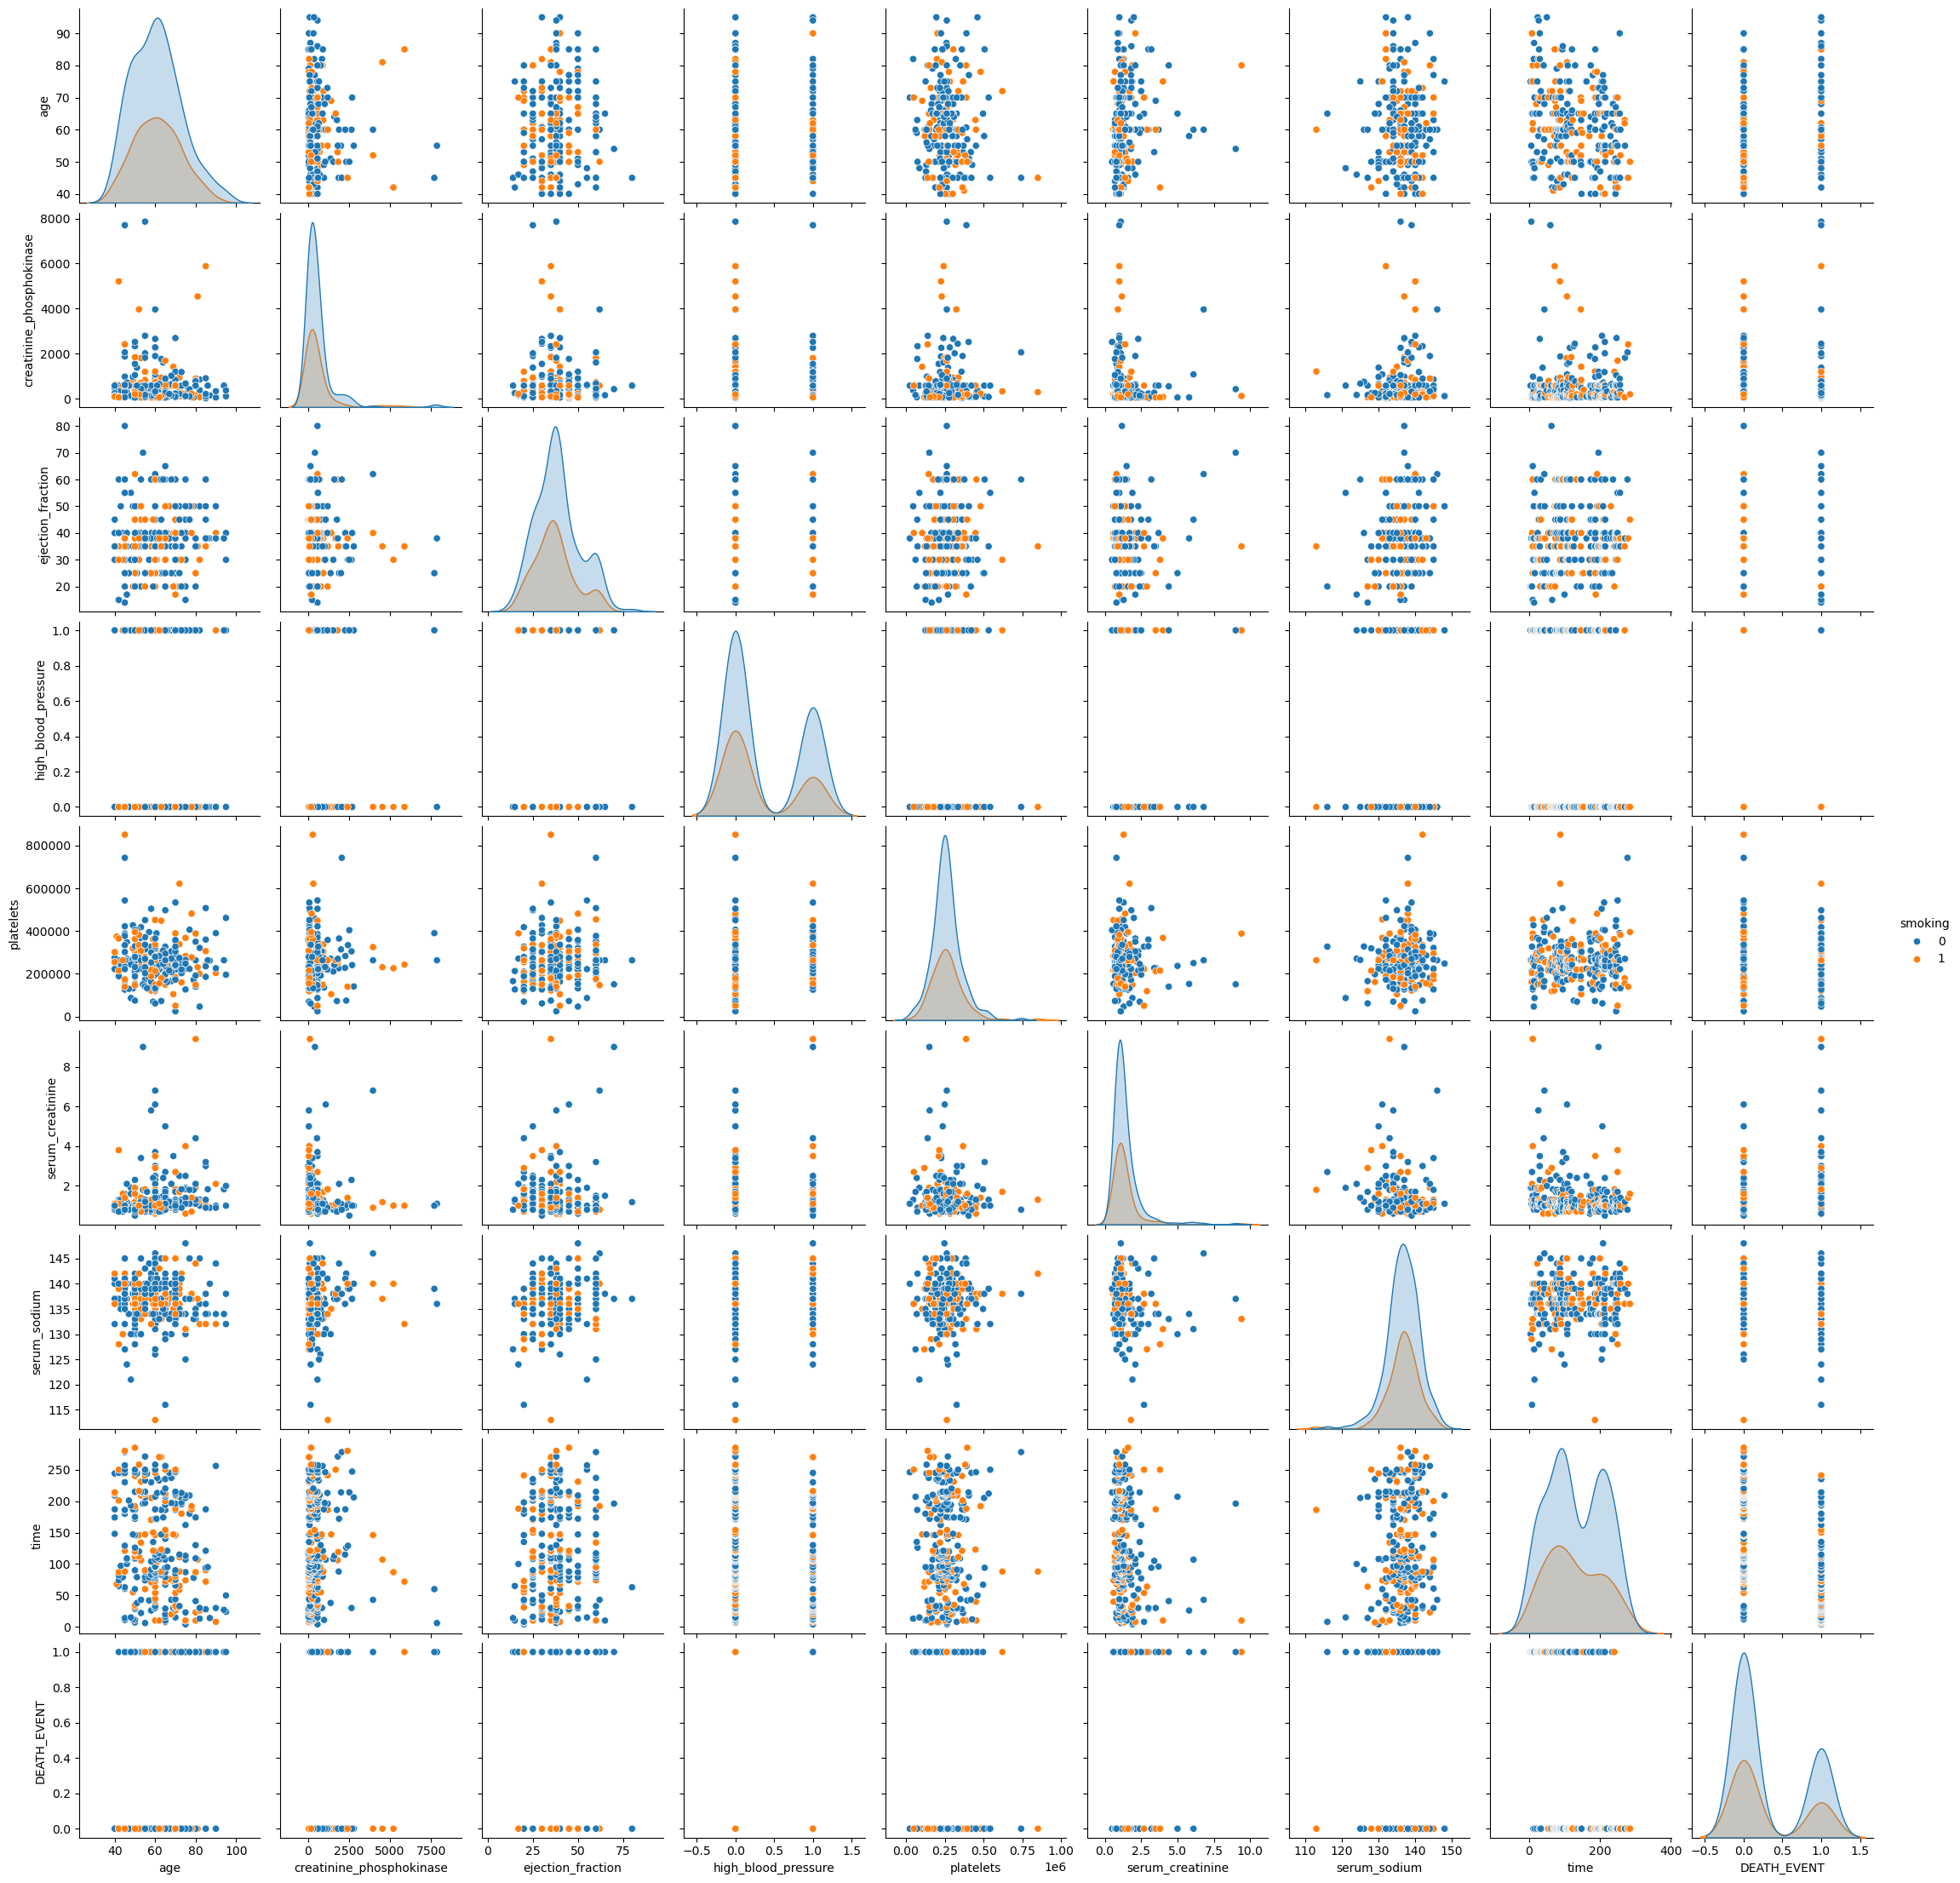

In [56]:
sns.pairplot(data=df, hue='smoking')
plt.show()

###  Identificación de datos faltantes
---

In [60]:
df.isna()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,False,False,False,False,False,False,False,False,False,False,False,False,False
295,False,False,False,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,False,False,False


In [61]:
# Contar la proporción de valores nulos en cada columna
df.isna().sum() 

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [62]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100  # round(4) redondea a 4 decimales

age                         0.0
anaemia                     0.0
creatinine_phosphokinase    0.0
diabetes                    0.0
ejection_fraction           0.0
high_blood_pressure         0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
sex                         0.0
smoking                     0.0
time                        0.0
DEATH_EVENT                 0.0
dtype: float64

No tienen NA, no tiene faltantes el data set.